# Notebook 3 Overview – Modeling and Risk Analysis

## Project Overview 

This project analyzes a dataset of 614 loan applications to understand the factors influencing loan approval and to develop a framework for assessing credit risk. The analysis includes exploratory data analysis, feature engineering, and predictive modeling using Logistic Regression and XGBoost.

The project is divided into three parts:

1. Data Quality and Cleaning  
2. Feature Engineering and Risk Analysis  
3. Credit Risk Modeling  

The dataset used in this project was obtained from: https://www.kaggle.com/datasets/burak3ergun/loan-data-set/data and contains demographic and financial information for 614 loan applicants.

### Approach

In this part of the project, the focus is on **predictive modeling and evaluating loan risk**. The goal is to identify the best predictive model for loan approval and use it to estimate an applicant’s Probability of Default (PD), categorizing them into three risk groups: Low, Medium, and High Risk.

The following steps are performed:

- Building a Logistic regression model with and without hyperparameter tuning on cleaned dataset
- Building a XGBoost model with and without hyperparameter tuning on original dataset
- Comparing models using accuracy, ROC-AUC score, f1 score, and ROC-AUC curves and deciding the best model for these metrics.
- Evaluate credit risk using best model and categorizing applicant in to three groups Low Risk - Medium Risk - High Risk based Probability of default.

### Business Context

Financial institutions use credit risk modeling to assess the likelihood of borrowers repaying loans. Poor lending decisions increase default risk and financial losses. By analyzing historical loan application data, predictive models identify patterns in borrower characteristics and financial indicators that influence loan approval.

In this project, the objective is to explore borrower characteristics and financial indicators that influence loan approval decisions and to develop a model that estimates the likelihood of loan approval.

### References

This project was developed with guidance from a tutorial series by Muhammad Faizin Zen on Medium, which explains the process of building a credit scoring model step-by-step. The articles were used as references for understanding typical preprocessing steps and modeling approaches used in credit risk analysis.

To better understand credit risk datasets and typical preprocessing approaches used in credit scoring, the following resources were used:

Articles on Medium by Muhammad Faizin Zen:

- Building a Credit Score Model: Model Selection, Training, and Evaluation (Feb 2025)
- Building a Credit Score Model: Hyperparameter Tuning for an Optimized Credit Scoring Model (Feb 2025)

Example by Louis Deconinck
- Credit Risk Modelling: Probability of Default (2023)


### Table of Contents

1. Project Overview  
2. Packages Used  
3. Downloading Data
4. Model Building
- 4.1 Logistic Regression 
   - 4.1.1 Without Hyperparameter tuning
   - 4.1.2 With Hyperparametertuning
- 4.2 XGBoost
   - 4.2.1 Without Hyperparameter tuning
   - 4.2.2 With Hyperparametertuning
- 4.3 Model comparison
5. Risk Assesment
- 5.1 Estimating Values for Credit Categorization
- 5.2 Plotting Risk Categories
6. Conlusion

# 2. Packages used

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report, auc,roc_curve, f1_score

from xgboost import XGBClassifier
from xgboost import plot_importance


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 3. Download data

In [2]:
#Logistic Regression
X_train_log = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets\Data_Logistic_Regression\X_train")
X_test_log = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets\Data_Logistic_Regression\X_test")
y_train_log = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets\Data_Logistic_Regression\y_train")
y_test_log = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets\Data_Logistic_Regression\y_test")

#XGBoost
X_train_xgb = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets\Data_XGBoost\X_train")
X_test_xgb = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets\Data_XGBoost\X_test")
y_train_xgb = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets\Data_XGBoost\y_train")
y_test_xgb = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets\Data_XGBoost\y_test")
print("Shape of training data for logistic regression:",X_train_log.shape,
      "\nShape of test data for logistic regression:",X_test_log.shape,
      "\nShape of training data for XGBoost:",X_train_xgb.shape,
      "\nShape of test data for XGBoost:",X_test_xgb.shape)
X_train_log.head()

Shape of training data for logistic regression: (491, 25) 
Shape of test data for logistic regression: (123, 25) 
Shape of training data for XGBoost: (491, 14) 
Shape of test data for XGBoost: (123, 14)


,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Total_Income,DTI,Dept_Ratio,Gender_Male,Married_Yes,Education_Not Graduate,...,Loan_Amount_Term_grouped_180.0,Loan_Amount_Term_grouped_360.0,Loan_Amount_Term_grouped_Other,Has_Coapplicant,Applicant_Income_log,Coapplicant_Income_log,Loan_Amount_log,Total_Income_log,DTI_log,Dept_Ratio_log
0,0,3254.0,0.0,50.0,3254.0,65.080000,65.080000,1,0,0,...,0,1,0,0,8.087948,0.000000,3.931826,8.087948,4.190866,4.190866
1,1,3315.0,0.0,96.0,3315.0,34.531250,34.531250,1,1,0,...,0,1,0,0,8.106515,0.000000,4.574711,8.106515,3.570413,3.570413
2,2,3340.0,1710.0,150.0,5050.0,33.666667,22.266667,1,1,0,...,0,1,0,1,8.114025,7.444833,5.017280,8.527342,3.545779,3.147022
3,1,2653.0,1500.0,113.0,4153.0,36.752212,23.477876,1,1,1,...,1,0,0,1,7.883823,7.313887,4.736198,8.331827,3.631044,3.197770
4,0,2620.0,2223.0,150.0,4843.0,32.286667,17.466667,1,1,0,...,0,1,0,1,7.871311,7.707063,5.017280,8.485496,3.505157,2.915967


# 4. Model building

I will be deciding which model I  will use based which gives the best result in accuraacy, ROC-AUC score, F1-score, and confusion marrix. The classification report is provided for completeness.

## 4.1 Logistic Regression

Compared models trained with default hyperparameters to models with optimized hyperparameters. This demonstrats how tuning improves predictive performance, model robustness, and generalization, providing evidence for selecting the most effective model for the data.

I will be dropping the original income and loan data for model building, so they wouldn't affect the model from containing outliers etc. These featuers will be needed later of calculating expected loss. Data will also be scaled using z-score standardization.

In [3]:
X_train = X_train_log.copy().drop(["Applicant_Income", "Coapplicant_Income", "Loan_Amount", 
                                   "Total_Income", "DTI", "Dept_Ratio"], axis=1)
y_train = y_train_log.copy().squeeze()
X_test = X_test_log.copy().drop(["Applicant_Income", "Coapplicant_Income", "Loan_Amount", 
                                   "Total_Income", "DTI", "Dept_Ratio"], axis=1)
y_test = y_test_log.copy().squeeze()

#For hyperparameter tuning
X_train_h = X_train_log.copy().drop(["Applicant_Income", "Coapplicant_Income", "Loan_Amount", 
                                   "Total_Income", "DTI", "Dept_Ratio"], axis=1)
y_train_h = y_train_log.copy().squeeze()
X_test_h = X_test_log.copy().drop(["Applicant_Income", "Coapplicant_Income", "Loan_Amount", 
                                   "Total_Income", "DTI", "Dept_Ratio"], axis=1)
y_test_h = y_test_log.copy().squeeze()

In [4]:
numeric_cols = X_train.select_dtypes(include="float64").columns

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

### 4.1.1 Without hyperparametertunning

In [5]:
logreg = LogisticRegression(max_iter=1000,random_state = 42)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_pred_prob = logreg.predict_proba(X_test)[:,1]
auc_logreg = roc_auc_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1score = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("ROC AUC Score:", auc_logreg)
print("F1-score:", f1score, "\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred),"\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8455284552845529
ROC AUC Score: 0.7645510835913313
F1-score: 0.8972972972972972 

Confusion Matrix:
 [[21 17]
 [ 2 83]] 

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.55      0.69        38
           1       0.83      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.87      0.76      0.79       123
weighted avg       0.86      0.85      0.83       123



### Logistic Regression Model Performance (No Hyperparameter Tuning)

The Logistic Regression model was evaluated on the test set with the following results:

- **Accuracy:** 0.846  
- **ROC AUC score:** 0.764  
- **F1 score:** 0.897  

#### Confusion Matrix (Loan Decisions)

| Actual \ Predicted | Not Approved (1) | Approved (0) |
|-------------------|---------------|----------------|
| Not Approved (1)       | 21 (True Positive) | 17 (False Negative) |
| Approved (0)   | 2 (False Positive) | 83 (True Negative) |

**Interpretation in the context of loan approvals:**

- **High recall for approved loans (0):** The model correctly identifies almost all eligible applicants, meaning very few qualified applicants are mistakenly rejected.  
- **Low recall for not approved loans (1):** Some ineligible applicants are incorrectly approved (17 cases), which could pose a risk to the lender.  
- **True Negatives (TN = 83):** Eligible applicants correctly approved.  
- **False Negatives (FN = 17):** Ineligible applicants incorrectly approved.  
- **True Positives (TP = 21):** Ineligible applicants correctly rejected.  
- **False Positives (FP = 2):** Eligible applicants incorrectly rejected.

### 4.1.2 With hyperparametertunning

Logistic regression hyperparameters were optimized using GridSearch with 5-fold cross-validation.

The regularization parameter C was tested across logarithmic values to balance bias and variance.
Both L1 and L2 penalties were evaluated to compare sparse vs stable coefficient estimation.

The ROC AUC metric was used because credit datasets are typically imbalanced, and AUC better measures the model’s ability to distinguish defaulters from non-defaulters.

In [6]:
# Define parameter grid
param_grid = [
    {
        "penalty": ["l1"],
        "solver": ["liblinear","saga"],
        "C": [0.01,0.1,1,10,100]
    },
    {
        "penalty": ["l2"],
        "solver": ["lbfgs","liblinear","saga"],
        "C": [0.01,0.1,1,10,100]
    }
]

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid[0],
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_, "\n")
print("Best ROC AUC (CV):", grid_search.best_score_)

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'saga'} 

Best ROC AUC (CV): 0.7269079649192368


In [7]:
# Initialize model
logreg_h = LogisticRegression(random_state=42, max_iter=1000, C=1, penalty = "l1", solver = "saga")

# Assuming X_train, y_train are your features and target
logreg_h.fit(X_train_h, y_train_h)

y_pred_h = logreg_h.predict(X_test_h)
y_pred_prob_h = logreg_h.predict_proba(X_test_h)[:, 1]  # probability of default

auc_logreg_h = roc_auc_score(y_test_h, y_pred_prob_h)
accuracy_h =accuracy_score(y_test_h, y_pred_h)
f1score_h = f1_score(y_test_h, y_pred_h)

# Metrics
print("Accuracy:", accuracy_h)
print("ROC AUC Score:", auc_logreg_h,)
print("F1-score:", f1score_h, "\n")
print("Confusion Matrix:\n", confusion_matrix(y_test_h, y_pred_h),"\n")
print("Classification Report:\n", classification_report(y_test_h, y_pred_h))

Accuracy: 0.8536585365853658
ROC AUC Score: 0.8538699690402477
F1-score: 0.903225806451613 

Confusion Matrix:
 [[21 17]
 [ 1 84]] 

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



### Logistic Regression Model Performance (Hyperparameter Tuning)

The Logistic Regression model was evaluated on the test set with the following results:

- **Accuracy:** 0.854  
- **ROC AUC score:** 0.854  
- **F1 score:** 0.903  

#### Confusion Matrix (Loan Decisions)

| Actual \ Predicted | Not Approved (1) | Approved (0) |
|-------------------|---------------|----------------|
| Not Approved (1)       | 21 (True Positive) | 17 (False Negative) |
| Approved (0)   | 1 (False Positive) | 84 (True Negative) |

**Interpretation in the context of loan approvals:**

- **High recall for approved loans (0):** The model correctly identifies almost all eligible applicants, meaning very few qualified applicants are mistakenly rejected.  
- **Low recall for not approved loans (1):** Some ineligible applicants are incorrectly approved (17 cases), which could pose a risk to the lender.  
- **True Negatives (TN = 84):** Eligible applicants correctly approved.  
- **False Negatives (FN = 17):** Ineligible applicants incorrectly approved.  
- **True Positives (TP = 21):** Ineligible applicants correctly rejected.  
- **False Positives (FP = 1):** Eligible applicants incorrectly rejected.

### 4.1.3 Most Important Features for Logistic Regression

Feature importance in evaluated on for the hyperparameter-tuned model tuning adjusts the coefficients to improve predictive performance, reducing the influence of noise and small effects. While the untuned model uses the same features, the relative importance ranking of the key predictors (e.g., Credit_History, Has_Coapplicant, financial ratios) remains largely unchanged. Focusing on the tuned model ensures that the interpretation reflects the most reliable and optimized version of the model, without redundancy from the untuned version

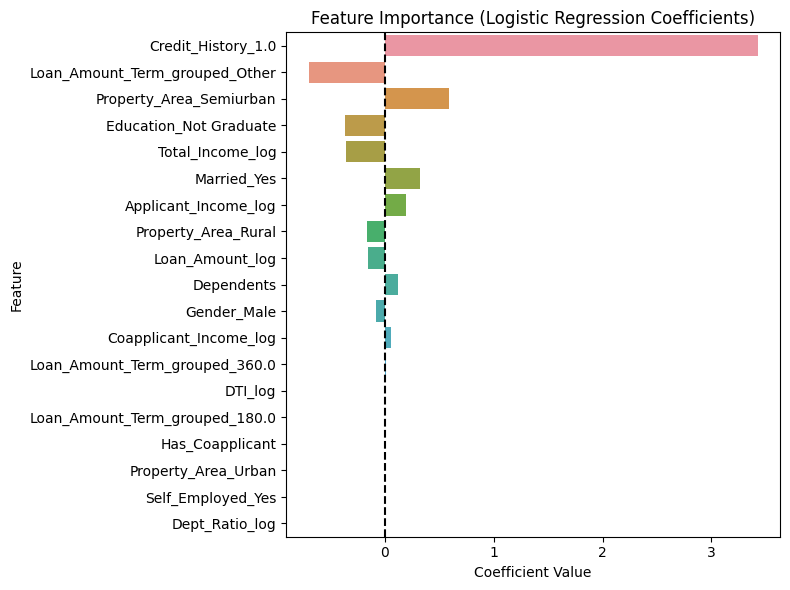

In [8]:
# Create dataframe
coefficients_h = pd.DataFrame({
    "Feature": X_train_h.columns,
    "Coefficient": logreg_h.coef_[0]
})

# Sort by importance
coefficients_h = coefficients_h.sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    data=coefficients_h,
    x="Coefficient",
    y="Feature"
)

plt.axvline(0, color="black", linestyle="--")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Section 4.1 Conclusion

Hyperparameter tunning moderately increases accuracy, ROC-AUC score, f1 score, and the models ability to predict to correctly approve loans.

The most important factor influencing loan approval are:
- Credit_History
- Property_Area_Semiurban
- Married_Yes
- Applicant_Income 

The most important factors influencing loan rejection are:
- Loan_Amount_Term_Other
- Education_Not Graduate 
- lower Total_Income
- Property_Area_Rural

## 4.2. XGBoost model

**Choice of Modeling Approach**

The dataset is relatively small, and exploratory analysis showed that highly flexible models such as XGBoost can achieve perfect performance, likely due to the dataset's limited size and structure rather than reflecting true predictive power. 

To avoid overfitting and demonstrate a robust baseline, a simpler and more interpretable model — Logistic Regression — is chosen for the main analysis. 

This allows for clearer interpretation of feature effects and avoids misleadingly perfect performance that may result from over-parameterized models on small datasets.

As a complementary experiment, XGBoost will also be applied to the original dataset, including missing values, to evaluate its ability to handle more extreme or unprocessed observations. 
This analysis helps assess model robustness and demonstrates how tree-based models can adapt to less-cleaned, more realistic data scenarios.

### 4.2.1 XGBoost without hyperparameter tuning

In [9]:
# create model with default parameters
xgb = XGBClassifier(random_state=42)

# train model
xgb.fit(X_train_xgb, y_train_xgb)

# predictions
y_pred_x = xgb.predict(X_test_xgb)
y_pred_prob_x = xgb.predict_proba(X_test_xgb)[:,1]

# evaluation
accuracy_x = accuracy_score(y_test_xgb, y_pred_x)
auc_x = roc_auc_score(y_test_xgb, y_pred_prob_x)
f1score_x = f1_score(y_test_xgb, y_pred_x)

print("Accuracy:", accuracy_x)
print("ROC AUC Score:", auc_x)
print("F1-score:", f1score_x, "\n")
print("Confusion Matrix:\n", confusion_matrix(y_test_xgb, y_pred_x),"\n")
print("Classification Report:\n", classification_report(y_test_xgb, y_pred_x))

Accuracy: 0.8048780487804879
ROC AUC Score: 0.7919504643962848
F1-score: 0.8604651162790696 

Confusion Matrix:
 [[25 13]
 [11 74]] 

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.66      0.68        38
           1       0.85      0.87      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.77       123
weighted avg       0.80      0.80      0.80       123



### Logistic Regression Model Performance (No Hyperparameter Tuning)

The Logistic Regression model was evaluated on the test set with the following results:

- **Accuracy:** 0.805 
- **ROC AUC score:** 0.792  
- **F1 score:** 0.860

#### Confusion Matrix (Loan Decisions)

| Actual \ Predicted | Not Approved (1) | Approved (0) |
|-------------------|---------------|----------------|
| Not Approved (1)       | 25 (True Positive) | 13 (False Negative) |
| Approved (0)   | 11 (False Positive) | 74 (True Negative) |

**Interpretation in the context of loan approvals:**

- **High recall for approved loans (0):** The model correctly identifies almost all eligible applicants, meaning very few qualified applicants are mistakenly rejected.  
- **Low recall for not approved loans (1):** Some ineligible applicants are incorrectly approved (17 cases), which could pose a risk to the lender.  
- **True Negatives (TN = 74):** Eligible applicants correctly approved.  
- **False Negatives (FN = 13):** Ineligible applicants incorrectly approved.  
- **True Positives (TP = 25):** Ineligible applicants correctly rejected.  
- **False Positives (FP = 11):** Eligible applicants incorrectly rejected.

### 4.2.2 XGBoost with hyperparameter tuning

In [10]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

xgb = XGBClassifier(random_state=42)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train_xgb, y_train_xgb)

best_model = search.best_estimator_
best_parameters = search.best_params_

print("Best parameters:", best_parameters)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [11]:
# create model with default parameters
xgb_h = XGBClassifier(random_state=42, subsample = 0.6, n_estimators = 100, max_depth = 5, learning_rate = 0.01,
                   colsample_bytree = 0.8)

# train model
xgb_h.fit(X_train_xgb, y_train_xgb)

# predictions
y_pred_x_h = xgb_h.predict(X_test_xgb)
y_pred_prob_x_h = xgb_h.predict_proba(X_test_xgb)[:,1]

# evaluation
accuracy_x_h = accuracy_score(y_test_xgb, y_pred_x_h)
auc_x_h = roc_auc_score(y_test_xgb, y_pred_prob_x_h)
f1score_x_h = f1_score(y_test_xgb, y_pred_x_h)

print("Accuracy:", accuracy_x_h)
print("ROC AUC Score:", auc_x_h,)
print("F1-score:", f1score_x_h, "\n")
print("Confusion Matrix:\n", confusion_matrix(y_test_xgb, y_pred_x_h),"\n")
print("Classification Report:\n", classification_report(y_test_xgb, y_pred_x_h))

Accuracy: 0.8536585365853658
ROC AUC Score: 0.8
F1-score: 0.903225806451613 

Confusion Matrix:
 [[21 17]
 [ 1 84]] 

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



### Logistic Regression Model Performance (Hyperparameter Tuning)

The Logistic Regression model was evaluated on the test set with the following results:

- **Accuracy:** 0.854  
- **ROC AUC score:** 0.787  
- **F1 score:** 0.903  

#### Confusion Matrix (Loan Decisions)

| Actual \ Predicted | Not Approved (1) | Approved (0) |
|-------------------|---------------|----------------|
| Not Approved (1)       | 21 (True Positive) | 17 (False Negative) |
| Approved (0)   | 1 (False Positive) | 84 (True Negative) |

**Interpretation in the context of loan approvals:**

- **High recall for approved loans (0):** The model correctly identifies almost all eligible applicants, meaning very few qualified applicants are mistakenly rejected.  
- **Low recall for not approved loans (1):** Some ineligible applicants are incorrectly approved (17 cases), which could pose a risk to the lender.  
- **True Negatives (TN = 84):** Eligible applicants correctly approved.  
- **False Negatives (FN = 17):** Ineligible applicants incorrectly approved.  
- **True Positives (TP = 21):** Ineligible applicants correctly rejected.  
- **False Positives (FP = 1):** Eligible applicants incorrectly rejected.

### 4.2.3 Most Important Features for XGBoost

<AxesSubplot:title={'center':'Feature importance'}, xlabel='Importance score', ylabel='Features'>

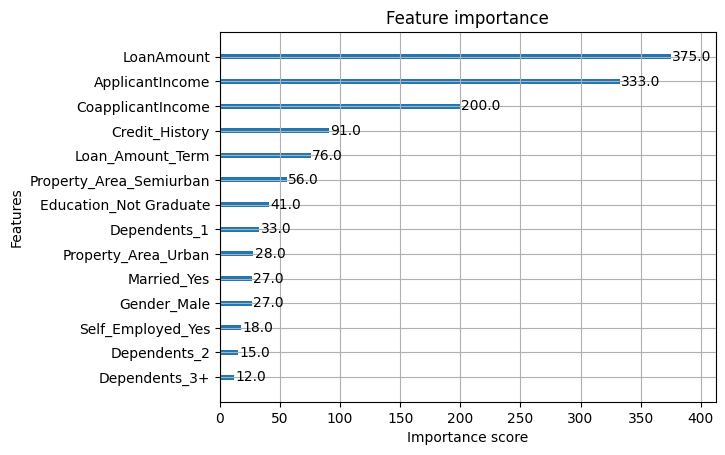

In [12]:
#Looking at which feature is the most important for the model
plot_importance(xgb_h)

### Section 4.2 Conclusion

Hyperparameter tunning significantly increased the models ability to predict to correctly approve loans. Accuracy, ROC-AUC score, and f1 score were moderently imporved.

The most important factor influencing loan approval are:
- Loan_Amount
- Applicant_Income
- Coapplicant_Income
- Credit_History

## 4.3. Comparing models for prediction

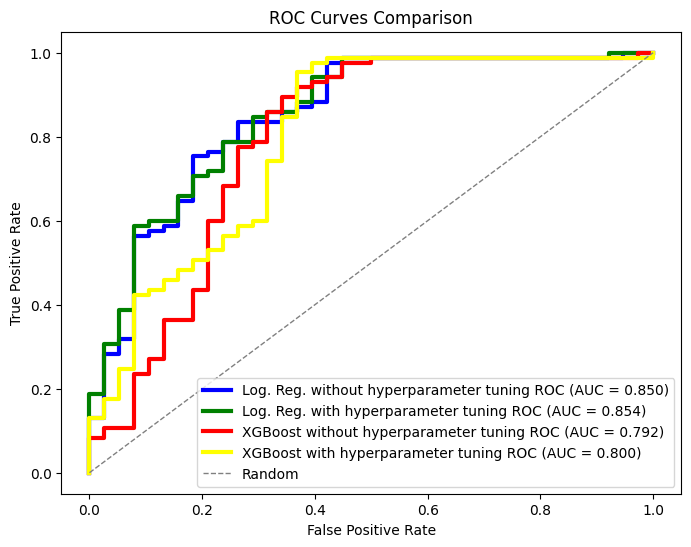

                         Model  Accuracy  F1 Score   ROC-AUC
0          Logistic Regression  0.845528  0.897297  0.849536
1  Logistic Regression with ht  0.853659  0.903226  0.853870
2                      XGBoost  0.804878  0.860465  0.791950
3              XGBoost with ht  0.853659  0.903226  0.800000


In [13]:
#Without hyperparameter tuning
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

#With hyperparameter tuning
fpr_h, tpr_h, thresholds_h = roc_curve(y_test_h, y_pred_prob_h)
auc_h = roc_auc_score(y_test_h, y_pred_prob_h)

#Without hyperparameter tuning
fpr_x, tpr_x, thresholds_x = roc_curve(y_test_xgb, y_pred_prob_x)
auc_x = roc_auc_score(y_test_xgb, y_pred_prob_x)

#With hyperparameter tuning
fpr_x_h, tpr_x_h, thresholds_x_h = roc_curve(y_test_xgb, y_pred_prob_x_h)
auc_x_h = roc_auc_score(y_test_xgb, y_pred_prob_x_h)

#Plotting ROC-AUC curves on top each other
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, color='blue', lw=3, label=f'Log. Reg. without hyperparameter tuning ROC (AUC = {auc:.3f})')
plt.plot(fpr_h, tpr_h, color='green', lw=3, label=f'Log. Reg. with hyperparameter tuning ROC (AUC = {auc_h:.3f})')

plt.plot(fpr_x, tpr_x, color='red', lw=3, label=f'XGBoost without hyperparameter tuning ROC (AUC = {auc_x:.3f})')
plt.plot(fpr_x_h, tpr_x_h, color='yellow', lw=3, label=f'XGBoost with hyperparameter tuning ROC (AUC = {auc_x_h:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

results = {
    #with ht =using hyperparameter tuning
    "Model": ["Logistic Regression","Logistic Regression with ht", "XGBoost", "XGBoost with ht"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_h),
        accuracy_score(y_test_xgb, y_pred_x),
        accuracy_score(y_test_xgb, y_pred_x_h)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_h),
        f1_score(y_test_xgb, y_pred_x),
        f1_score(y_test_xgb, y_pred_x_h)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_prob),
        roc_auc_score(y_test, y_pred_prob_h),
        roc_auc_score(y_test_xgb, y_pred_prob_x),
        roc_auc_score(y_test_xgb, y_pred_prob_x_h)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

### Selection 4. Conclusion 

**Summary:**  
The model chosen is conservative in approving loans, catching almost all eligible applicants but allowing some ineligible applicants through. This reflects a trade-off between maximizing loan approvals and minimizing default risk, which is common in credit scoring models.

After evaluating multiple models, Logistic Regression with hyperparameter tuning was selected as the final model for the credit loan prediction task.

The tuned Logistic Regression model achieved the best overall performance:

- **ROC-AUC:** 0.854
- **Accuracy:** 0.854
- **F1 Score:** 0.903

The ROC-AUC score indicates that the model performs best at separating approved and non-approved loan applicants, making it particularly suitable for classification in a credit risk context.

Although XGBoost achieved similar accuracy and F1 scores, its ROC-AUC was lower, indicating weaker class separation. Additionally, Logistic Regression offers a key advantage in credit risk modeling: interpretability. Financial decision-making often requires transparent models that allow stakeholders to understand how predictions are made. Logistic Regression provides clear coefficient-based explanations, which is important for risk assessment, auditing, and regulatory compliance.

A comparison of the ROC curves for the hyperparameter-tuned models further confirms that Logistic Regression demonstrates stronger discriminatory ability across probability thresholds. The confusion matrices of both models were also very similar, suggesting comparable classification behavior.

For the final Logistic Regression model, the confusion matrix results were:

- **True Positives (Approved correctly):** 84  
- **False Positives (Approved incorrectly):** 17  
- **True Negatives (Not approved correctly):** 21  
- **False Negatives (Not approved incorrectly):** 1  

These results indicate that the model successfully identifies most eligible applicants while maintaining reasonable control over incorrect approvals.

### Final Decision

Overall, the tuned Logistic Regression model provides the best balance between:

- **Predictive performance**
- **Model interpretability**
- **Practical suitability for credit risk analysis**

This demonstrates a **quantitative, data-driven approach to model selection**, ensuring that both statistical performance and real-world considerations are taken into account.

# 5. Risk Assessment

Due to limited data about applicant and coapplicant income, loan amount, and credit history, traditional credit risk parameters such as Probability of Default (PD), Exposure at Default (EAD), and Loss Given Default (LGD) could not be fully calculated. In particular, EAD could not be derived from the dataset and is therefore ignored. 

Instead, risk-related features such as Debt-to-Income (DTI) and Loan-to-Income (LTI) ratios were used as proxies for repayment stress. For simplicity, all loans were assumed to be senior unsecured exposure, and a conservative LGD of 50 was applied (Basel II Glossary, 2013: https://web.archive.org/web/20130421005422/http://www.basel-ii-risk.com/Basel-II/Basel-II-Glossary/Loss-Given-Default.htm). 

A conservative risk categorization was implemented based on predicted PD from the model: 
- **Low Risk (PD < 0.10):** Mostly eligible applicants automatically approved. 
- **Medium Risk (0.10 ≤ PD < 0.50):** Borderline cases flagged for manual review to prevent approving risky applicants. 
- **High Risk (PD ≥ 0.50):** Likely ineligible applicants rejected automatically to minimize default risk. 

I came to this conclusion from the results of the confusion matrix: 
- **True Negatives (TN = 84):** Eligible applicants correctly approved → aligns with Low Risk category. 
- **False Negatives (FN = 17):** Ineligible applicants incorrectly approved → mostly Medium Risk, highlighting the need for manual review. 
- **True Positives (TP = 21):** Ineligible applicants correctly rejected → aligns with High Risk category. 
- **False Positives (FP = 1):** Eligible applicants incorrectly rejected → very few, indicating a cautious but not overly restrictive model. 

**Interpretation:** This conservative PD-based thresholding balances maximizing approvals for safe applicants while minimizing potential losses from risky applicants. By applying model-driven risk categories, lenders can identify potential exposure concentrations and prioritize manual review for borderline cases, ensuring a practical and explainable credit risk framework

## 5.1 Estimating Values for Credit Risk Categorization

In [14]:
X_train_r = X_train_log.copy().drop(["Applicant_Income_log", "Coapplicant_Income_log", "Loan_Amount_log", 
                                   "Total_Income_log", "DTI_log", "Dept_Ratio_log"], axis=1)
y_train_r = y_train_log.copy()
X_test_r = X_test_log.copy().drop(["Applicant_Income_log", "Coapplicant_Income_log", "Loan_Amount_log", 
                                   "Total_Income_log", "DTI_log", "Dept_Ratio_log"], axis=1)
y_test_r = y_test_log.copy()

In [15]:
#Probability of a loan being approved. Using testing data containing scaled values
prababilities = logreg_h.predict_proba(X_test)[:, 1]
X_test_r["Probability_Approved"] = prababilities 

#Adding Loan_Status as Loan_Approved to data set
X_test_r["Loan_Approved"] = y_test_log.values

#Calculating Probability of default (PD)
PD = 1 - X_test_r["Probability_Approved"]
X_test_r["PD"] =PD

#assigning risk category
def risk_bucket(pd):
    if pd <= 0.10:
        return "Low Risk"
    elif pd > 0.10 and pd < 0.50:
        return "Medium Risk"
    else:
        return "High Risk"
    
X_test_r["Risk_Category"] = X_test_r["PD"].apply(risk_bucket)
 
#Caluclation of expected loss when default happens
LGD = 0.5
X_test_r["Expected_Loss"] = X_test_r["PD"] * X_test_r["Loan_Amount"] * LGD

#A summary table of how many applicantsm the average PB of applicans, Total amount of loan, and total expected loss per 
#risk_category
summary = X_test_r.groupby("Risk_Category").agg(
    Num_Applicants=("Loan_Amount", "count"),
    Avg_PD=("PD", "mean"),
    Total_Loan_Amount=("Loan_Amount", "sum"),
    Total_Expected_Loss=("Expected_Loss", "sum")
).reset_index()

summary["Avg_PD"] = (summary["Avg_PD"] * 100).round(1)  # convert to %
summary["Total_Expected_Loss"] = summary["Total_Expected_Loss"].round(0)
summary

,Risk_Category,Num_Applicants,Avg_PD,Total_Loan_Amount,Total_Expected_Loss
0,High Risk,14,62.9,2384.0,739.0
1,Low Risk,97,3.9,13548.0,287.0
2,Medium Risk,12,30.6,1617.0,225.0


There are 14 High Risk applicant that have total of 2384 of loan and the expected loss in 739, there 97 low risk applicants 13548 of loan and expected loss 387, and 12 medium risk loaners who have 1617 of total loan and expected loss of 225

In [16]:
#Precantage of loans rejected/approved per group
(pd.crosstab(X_test_r["Risk_Category"], X_test_r["Loan_Approved"],normalize="index"))*100

Loan_Approved,0,1
Risk_Category,,
High Risk,92.857143,7.142857
Low Risk,15.463918,84.536082
Medium Risk,83.333333,16.666667


83% of medium risk were rejected. 92% of high risk loans were rejected and 85% of low risk loans were approved

## 5.2 Plotting Risk categories agains loan approval

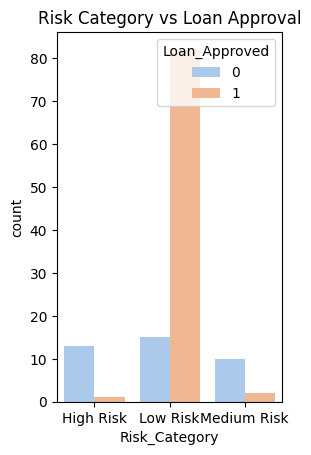

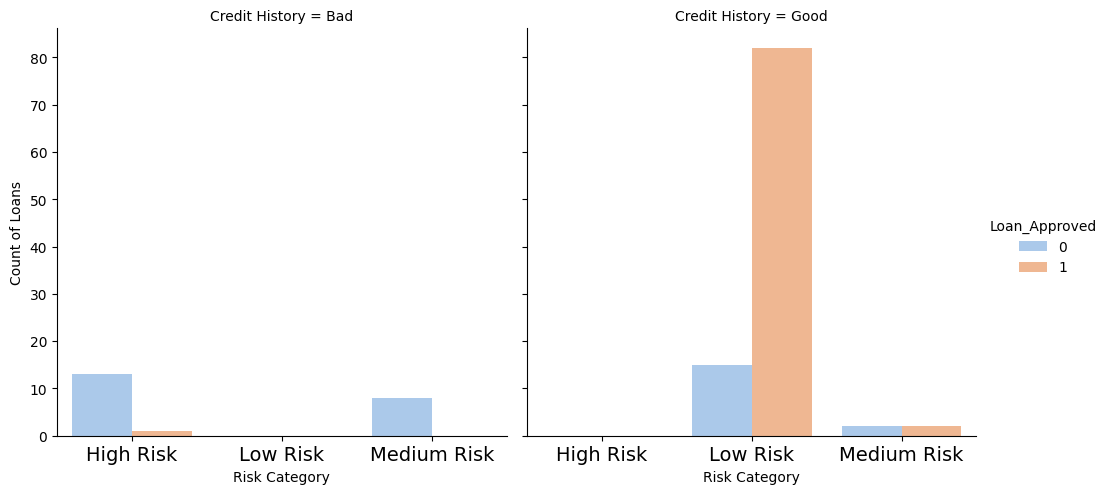

In [17]:
plt.subplot(1, 2, 2)

sns.countplot(data=X_test_r, x="Risk_Category", hue="Loan_Approved", palette ="pastel")
plt.title("Risk Category vs Loan Approval")

plt.subplot(1, 2, 2)
X_test_r["Credit_History_Label"] = X_test_r["Credit_History_1.0"].map({0: "Bad", 1: "Good"})

g = sns.catplot(
    data=X_test_r,
    x="Risk_Category",
    hue="Loan_Approved",
    col="Credit_History_Label",   # creates separate subplot for each credit history
    kind="count",
    palette="pastel",
    height=5,
    aspect=1
)
g.set_axis_labels("Risk Category", "Count of Loans")
g.set_titles("Credit History = {col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelsize=14)
plt.show()

From the plots, we can observe the following patterns regarding credit history and loan approval:

- Applicants with a good credit history are predominantly categorized as low risk, and the majority of these loans are approved.

- Applicants with a bad credit history are generally classified as medium or high risk. While most of these high-risk applicants are denied, a small number of them still receive loan approvals.

- For medium-risk applicants, the effect of credit history is mixed:

  - Those with a bad credit history are more likely to have their loans rejected.

  - Those with a good credit history have roughly a 50/50 chance of approval, indicating that other factors beyond credit history influence the decision.

These observations highlight the strong predictive value of credit history in assessing loan risk, while also emphasizing that loan approval decisions are influenced by multiple financial and demographic factors.

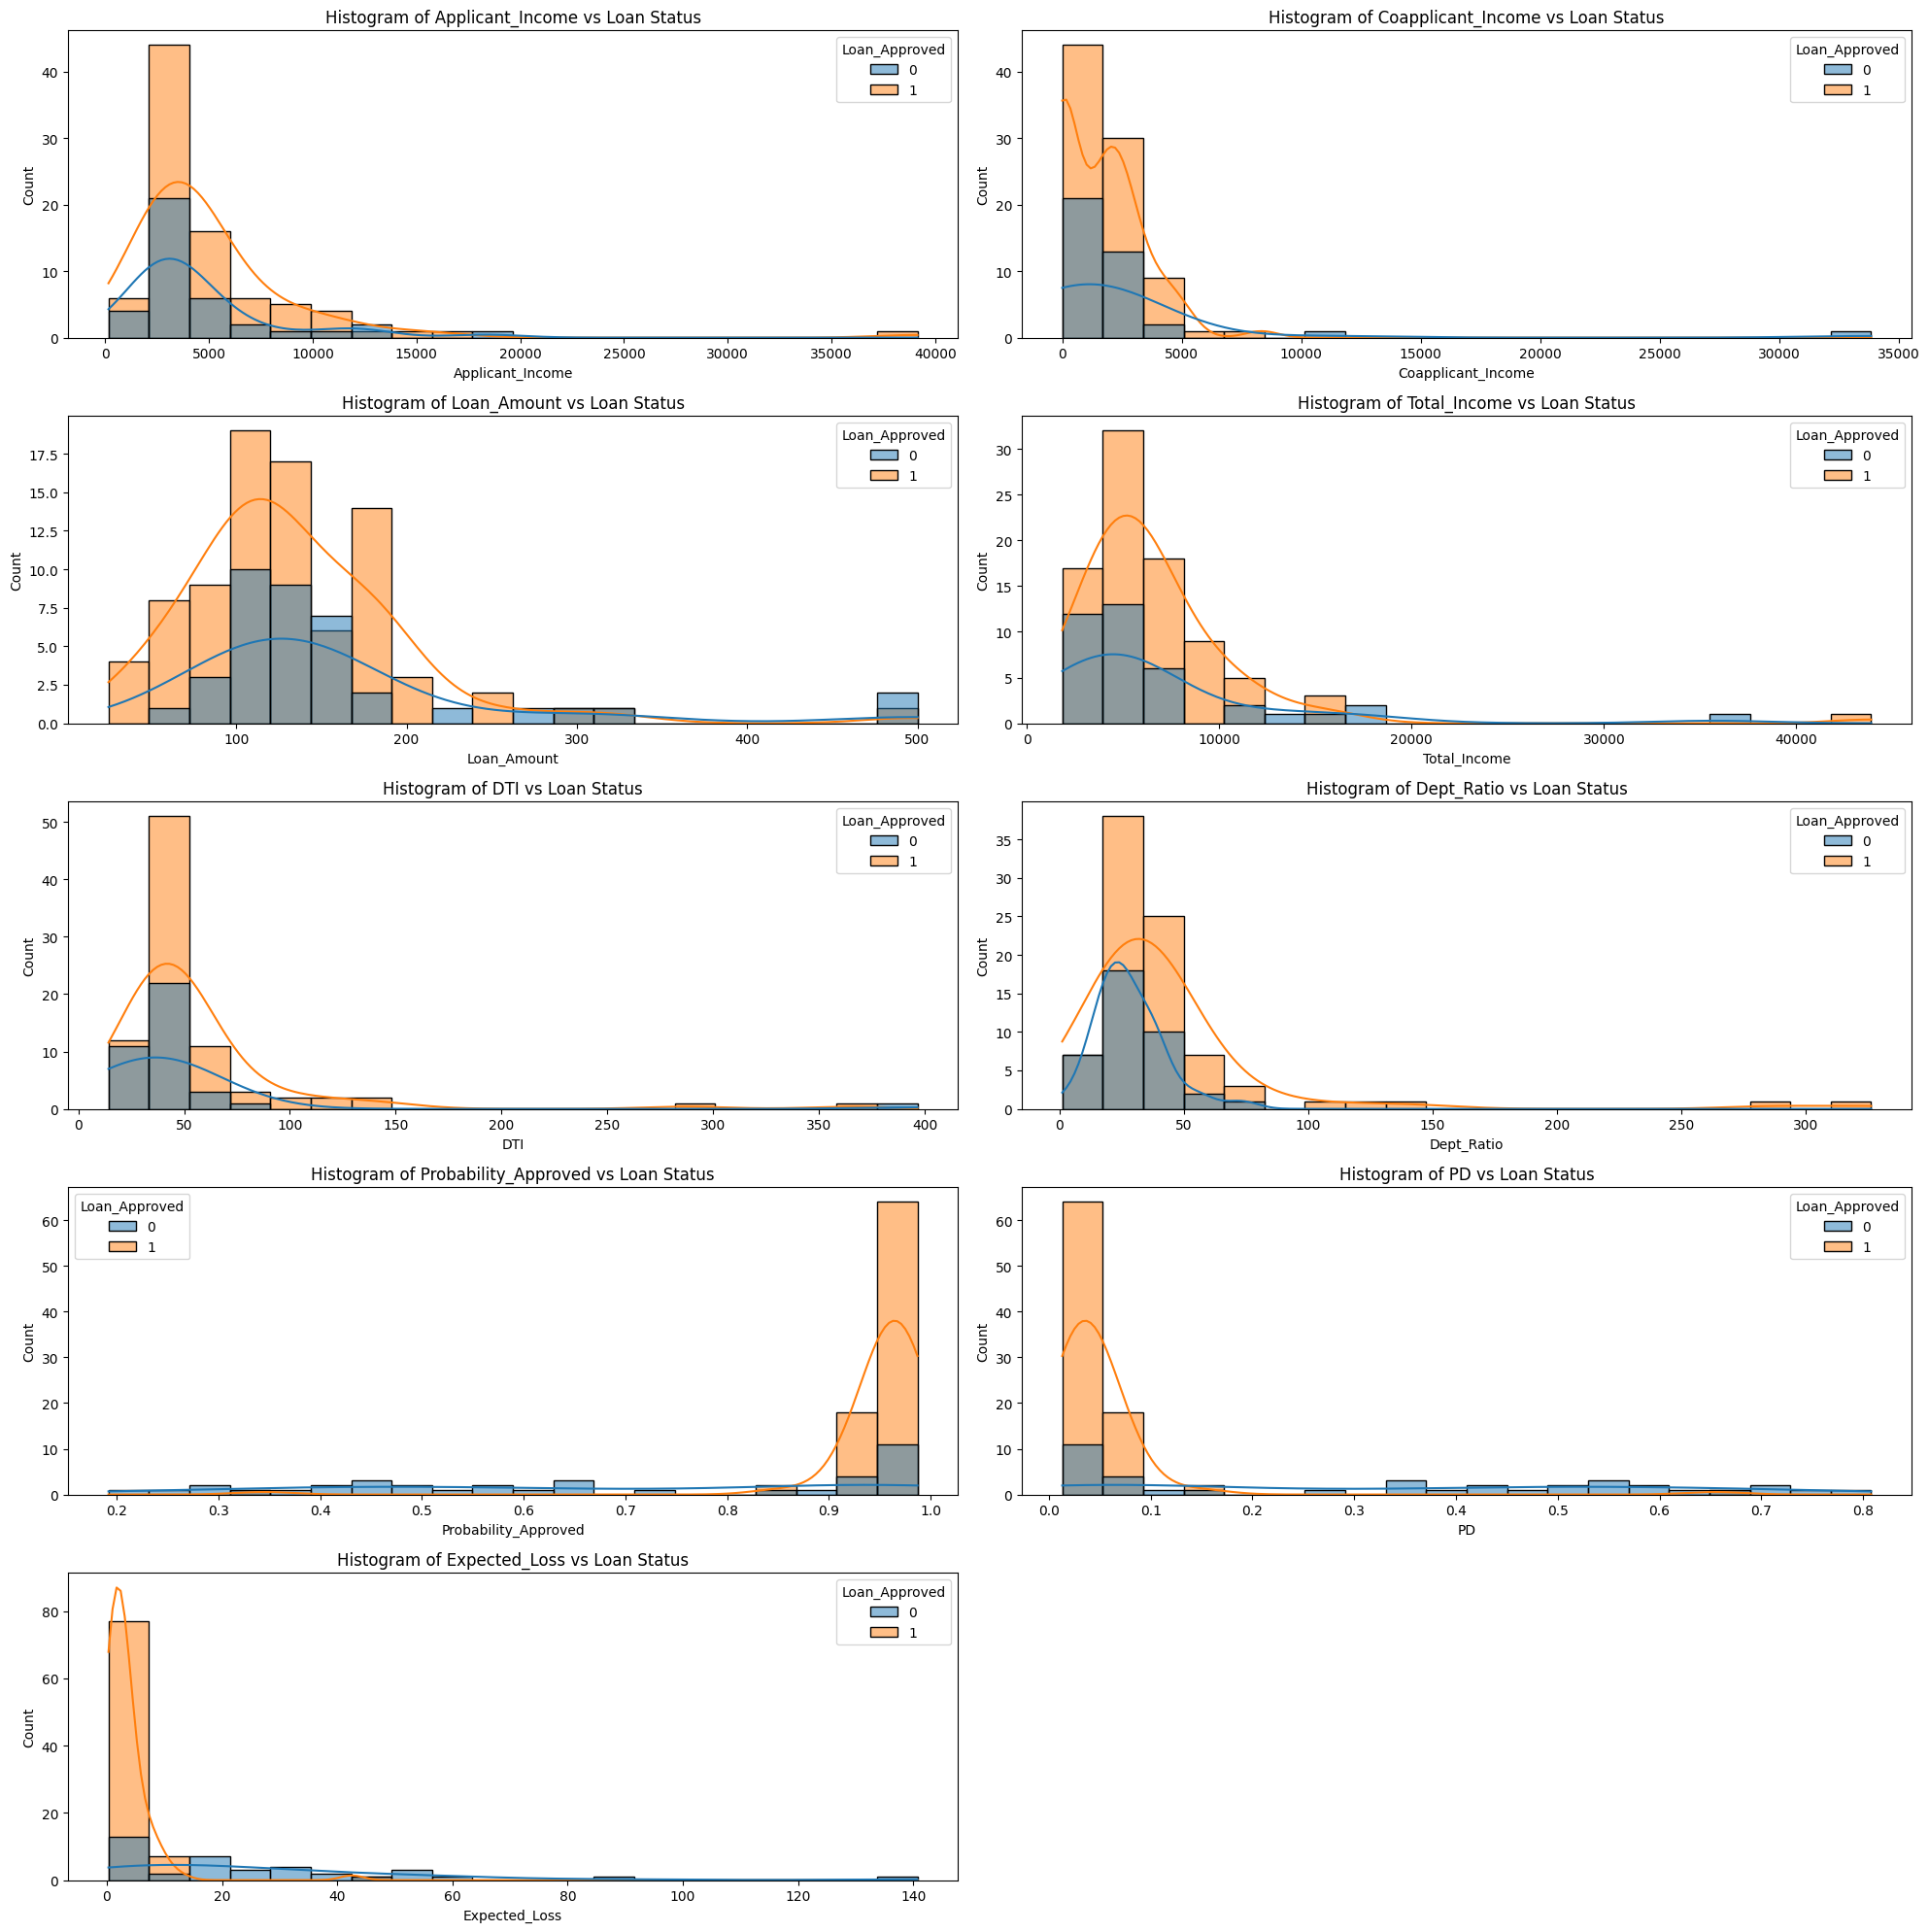

In [18]:
numeric_cols = X_test_r.select_dtypes(include="float64").columns.tolist()
plt.figure(figsize=(20,20))


for i,col in enumerate(numeric_cols):
    plt.subplot(5, 2, i+1)


    # Histogram
    sns.histplot(data=X_test_r, x=col, hue="Loan_Approved", bins=20, kde=True)   
    plt.title(f"Histogram of {col} vs Loan Status")

plt.tight_layout()
plt.show()


From the analysis, we can observe several trends related to loan approval:

- Expected Loss: Loans with a small expected loss are almost always approved, indicating that lenders prioritize minimizing potential risk.

- Loan Amount: As the loan amount increases, the likelihood of rejection also increases. Interestingly, there is a sweet spot around a loan of approximately 180 where approval probability remains high, possibly reflecting common loan sizes that lenders are comfortable with.

- Income Effects:

  - A higher applicant income generally increases the likelihood of loan approval.

  - Conversely, a higher co-applicant income appears to slightly decrease the likelihood of approval, suggesting that the lender may consider total household debt or other risk factors associated with co-applicants.

These insights help understand how financial metrics and loan characteristics influence approval decisions and risk assessment.

# 7. Conclusion

In this notebook, multiple predictive models were developed and evaluated to estimate loan approval likelihood, comparing the impact of preprocessing, feature engineering, and hyperparameter tuning on model performance.  

**Logistic Regression**:  
A baseline Logistic Regression model was first trained on the processed dataset. Hyperparameter tuning was applied to optimize model performance, leading to modest but meaningful improvements in accuracy and ROC-AUC. The tuned Logistic Regression model maintained interpretability while providing reliable predictive performance, making it suitable for risk assessment.  

**XGBoost**:  
The XGBoost model was trained on the original dataset, with and without hyperparameter tuning. This approach demonstrated robustness to skewed and missing data, achieving strong accuracy and F1 scores even without extensive feature engineering. While XGBoost performed well, its interpretability is lower than Logistic Regression, making it less ideal for contexts where transparency is critical.  

**Model Comparison**:  
Models were compared using accuracy, ROC-AUC, and F1 score. Logistic Regression benefited most from preprocessing and feature engineering, whereas XGBoost performed well with raw features. Both models consistently identified **Credit_History**, **Has_Coapplicant**, and key financial variables—such as Applicant_Income and LoanAmount as the most influential predictors of loan approval.  

**Risk Analysis**:  
The final selected model (Logistic Regression with hyperparameter tuning) was used to estimate the **probability of default (PD)** for each applicant. Applicants were conservatively categorized into **Low, Medium, and High Risk** based on PD thresholds. This risk segmentation aligns with business objectives: maximizing approvals for safe applicants while minimizing potential losses from risky applicants. The confusion matrix demonstrates that most eligible applicants are correctly approved, borderline cases are flagged for review, and high-risk applicants are largely rejected, supporting data-driven, actionable decision-making.  

**Final Insights**:  
- Preprocessing, feature engineering, and hyperparameter tuning improve model performance and stability.  
- Logistic Regression offers a transparent and interpretable framework for credit risk assessment.  
- XGBoost is a robust alternative but trades interpretability for flexibility.  
- Risk categorization using predicted PD provides a practical framework for loan approval strategies, ensuring that high-risk applicants are identified while safe applicants are efficiently approved.  

Overall, this notebook demonstrates how careful data preparation, model selection, and risk-aware evaluation can provide **a reliable, interpretable, and actionable framework for assessing loan applications and supporting credit decisions**.